# DATA 612 — Project 3: Matrix Factorization Methods
**Zoran Glisovic**
**DATA 612 — Recommender Systems, Summer 2026**

---

## Building Toward 0.8567

Project 1 established a global-mean-plus-bias baseline. Project 2 added taste through content-based filtering and two flavors of memory-based collaborative filtering (UBCF and IBCF), landing on a best result of **IBCF, Pearson similarity, k=20 — RMSE 0.9186, MAE 0.7164**. Both UBCF and IBCF only use the ratings that are actually present in the data: similarity is computed over the overlap between two users (or two items), and missing entries never enter the calculation. That sidesteps the missing-value problem but caps how much signal the model can extract — every prediction is just a weighted vote among whichever neighbors happen to overlap with the target.

Project 3 introduces **matrix factorization**, specifically the SVD-style approach popularized by Simon Funk during the original Netflix Prize. Rather than computing similarities between full rating vectors, SVD assumes the rating matrix is approximately the product of two much smaller matrices — a *k*-dimensional latent factor vector for every user and every item. Predicting a rating is just a dot product between the two.

**Why this matters for missing values specifically:** the assignment notes that "SVD requires that there are no missing values," with three standard fixes — (1) imputation, (2) mean-centering, or (3) the advanced route, simulating SVD with SGD so the factorization never needs the missing entries filled in at all. This notebook uses `scikit-surprise`'s `SVD`, which implements option (3): Simon Funk's stochastic gradient descent learns the latent factors directly from the *observed* ratings only, with regularization preventing the model from overfitting to users or items that have very few ratings. No imputation step is needed — the 91.5% of the matrix that's empty is simply never touched.

The dashed red line on the results chart is still **0.8567**, the Netflix Prize winning RMSE.

---
## 1. The Math: SVD as Dimensionality Reduction

In its exact textbook form (MMDS §11.3), SVD factors a ratings matrix $M$ as:

$$M = U \Sigma V^T$$

where $U$ is users × $r$, $V$ is items × $r$, and $\Sigma$ is an $r \times r$ diagonal matrix of singular values ranked by how much variance each one explains. Truncating $\Sigma$ to its top $k$ values — and dropping the corresponding columns of $U$ and $V$ — gives the best possible rank-$k$ approximation of $M$ in the least-squares sense. As Prof. Kowalchuk framed it in the Week 3 session: you're not just compressing the matrix, you're discarding the ratings that "don't give a lot of information" — the equivalent of a single odd rating that doesn't reflect a user's real taste.

This textbook form has a hard requirement, though: it needs a *complete* matrix. Real ratings matrices are 90%+ empty, so the exact SVD can't be computed directly.

**Simon Funk's approach** (the one this notebook implements, following Koren, Bell & Volinsky 2009) sidesteps that requirement entirely. Instead of factoring a complete matrix, it *learns* two factor matrices — $P$ (users × $k$) and $Q$ (items × $k$) — by gradient descent, training only on the ratings that actually exist:

$$\hat{r}_{ui} = \mu + b_u + b_i + q_i^T p_u$$

where $\mu$ is the global mean and $b_u$, $b_i$ are user and item bias terms. The model never sees the missing entries, so there's nothing to impute. Regularization ($\lambda$, the `reg_all` parameter below) keeps the factors from overfitting users or items with very few ratings — functionally similar to how `KNNWithMeans` regressed toward the mean for thin neighborhoods in Project 2, but built into the optimization objective directly rather than bolted on as a fallback.

In [1]:
# --- Imports and setup ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

from surprise import Dataset, Reader, SVD
from surprise.model_selection import cross_validate, KFold, train_test_split

np.random.seed(42)
DATA_PATH = '../Resources/Netflix Prize data/'

---
## 2. Load Dataset

Same subset as Project 2, for direct comparability: the **500 most-rated movies**, restricted to users who rated at least **30** of them.

**Note on running this notebook:** it expects the Netflix Prize ratings files locally at `../Resources/Netflix Prize data/` (same path used in Projects 1 and 2). That raw data isn't included in this GitHub repo due to its size, so `DATA_PATH` below needs to point to wherever that data lives locally to re-run end to end.

In [2]:
import os

netflix_file = DATA_PATH + 'combined_data_1.txt'
if not os.path.exists(netflix_file):
    raise FileNotFoundError(
        f"Could not find {netflix_file}. Update DATA_PATH above to point to a local "
        "copy of the Netflix Prize ratings data (not included in this repo)."
    )

def parse_netflix_file(filepath, max_rows=3_000_000):
    """Read Netflix Prize format (movie_id:\n user_id,rating,date) into a flat DataFrame."""
    records = []
    current_movie = None
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line.endswith(':'):
                current_movie = int(line[:-1])          # movie header line
            else:
                user_id, rating, _ = line.split(',')
                records.append((current_movie, int(user_id), int(rating)))
                if len(records) >= max_rows:
                    break
    return pd.DataFrame(records, columns=['movie_id', 'user_id', 'rating'])

raw = parse_netflix_file(DATA_PATH + 'combined_data_1.txt')
top_movies = raw['movie_id'].value_counts().head(500).index   # 500 most-rated movies
sub = raw[raw['movie_id'].isin(top_movies)]
active = sub.groupby('user_id')['movie_id'].nunique()
df = sub[sub['user_id'].isin(active[active >= 30].index)].copy()  # users with ≥30 ratings in subset

nf_movies = pd.read_csv(
    DATA_PATH + 'movie_titles.csv', encoding='latin-1', header=None,
    names=['movie_id', 'year', 'title'], on_bad_lines='skip'
)
title_map = nf_movies.set_index('movie_id')['title'].to_dict()   # movie_id → title lookup

n_cells = df.user_id.nunique() * df.movie_id.nunique()
print(f'Users:    {df.user_id.nunique():>8,}')
print(f'Movies:   {df.movie_id.nunique():>8,}')
print(f'Ratings:  {len(df):>8,}')
print(f'Sparsity: {1 - len(df) / n_cells:>8.2%}')

Users:      14,339
Movies:        500
Ratings:   607,332
Sparsity:   91.53%


---
## 3. SVD — Latent Factor Sweep (k)

$k$ is the number of latent factors — the dimensionality of the concept space each user and item gets mapped into. The assignment PDF uses 20 and 70 as example values; I test both plus 50 in between. Same evaluation pattern as Project 2: 5-fold cross-validation, RMSE and MAE, fixed seed for reproducibility.

In [3]:
reader = Reader(rating_scale=(1, 5))          # surprise requires explicit rating scale
data   = Dataset.load_from_df(df[['user_id', 'movie_id', 'rating']], reader)
kf     = KFold(n_splits=5, random_state=42)   # shared fold splitter for all sweeps

def run_cv(algo, label):
    """Run 5-fold cross-validation and return mean RMSE and MAE."""
    cv   = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=kf, n_jobs=-1, verbose=False)
    rmse = cv['test_rmse'].mean()
    mae  = cv['test_mae'].mean()
    print(f'{label:<25}  RMSE: {rmse:.4f}   MAE: {mae:.4f}')
    return {'label': label, 'rmse': rmse, 'mae': mae}

k_results = []
for k in [20, 50, 70]:
    algo = SVD(n_factors=k, random_state=42)  # default reg_all=0.02
    k_results.append({**run_cv(algo, f'SVD k={k}'), 'k': k, 'reg_all': 0.02})

SVD k=20                   RMSE: 0.9126   MAE: 0.7151
SVD k=50                   RMSE: 0.9165   MAE: 0.7183
SVD k=70                   RMSE: 0.9184   MAE: 0.7202


**k=20 wins**, and by a wider margin than expected going in. More latent factors didn't help here — with only 500 movies and a 30-rating floor per user, there may not be enough independent signal to support 70 separate dimensions without some of them fitting noise. This is worth flagging: more factors is not automatically better, and the cost of testing a smaller k is much lower at inference time.

**Why this happens:** k sets how many numbers describe each user and each movie, so it directly controls the model's capacity. A larger k gives SGD more room to represent real taste structure, but it also gives it more parameters to fit to whatever is in the training ratings, signal or noise. With 607K ratings spread across 14,339 users and 500 movies, there is only so much real structure to find. Once k passes that ceiling, the extra dimensions may stop capturing genuine taste patterns and start fitting whatever happens to be in this particular training split instead. That is the bias-variance tradeoff showing up through the number of latent dimensions rather than through a different model family: a bigger k can in principle lower bias because it makes the model more expressive, but here it appears to raise variance faster than it lowers bias. The RMSE increase from 0.9126 at k=20 to 0.9184 at k=70 suggests that this 500-movie, 30-rating-floor dataset did not contain enough independent signal to support 70 useful latent dimensions.

---
## 4. Regularization Sweep

`reg_all` controls how strongly the optimization shrinks $p_u$, $q_i$, $b_u$, and $b_i$ toward zero — the SVD equivalent of Project 2's neighborhood-size tuning. Too little regularization and the model overfits thin users/items; too much and every prediction collapses toward the global mean. Sweeping at the best k found above (k=20).

In [4]:
reg_results = []
for reg in [0.01, 0.02, 0.05, 0.1]:
    algo = SVD(n_factors=20, reg_all=reg, random_state=42)  # fix k=20, vary regularization
    reg_results.append({**run_cv(algo, f'SVD k=20 reg={reg}'), 'k': 20, 'reg_all': reg})

SVD k=20 reg=0.01          RMSE: 0.9258   MAE: 0.7229
SVD k=20 reg=0.02          RMSE: 0.9126   MAE: 0.7151
SVD k=20 reg=0.05          RMSE: 0.9255   MAE: 0.7290
SVD k=20 reg=0.1           RMSE: 0.9391   MAE: 0.7419


`surprise`'s default (`reg_all=0.02`) turns out to already be the best setting tested — both lower (0.01) and higher (0.05, 0.1) regularization make RMSE worse. At 0.01 the model is likely overfitting slightly; by 0.1 it's clearly underfitting, with RMSE degrading toward the global-baseline range from Project 1. The best overall configuration is **SVD, k=20, reg_all=0.02 — RMSE 0.9126, MAE 0.7151**.

**What regularization is actually doing:** the SGD objective from Section 1 is not just minimizing squared error on observed ratings. It minimizes squared error plus $\lambda(b_u^2 + b_i^2 + \|p_u\|^2 + \|q_i\|^2)$, where $\lambda$ is `reg_all`. That penalty term shrinks every bias term and every factor vector toward zero, and it affects users and movies with few ratings the most, since their factors are not supported by much data in the first place. At `reg_all=0.01`, that shrinkage is too weak. A user with only a handful of ratings can still end up with a factor vector that fits those few ratings closely without generalizing, which is the same overfitting problem as the k sweep above, just coming from unconstrained parameter size instead of unconstrained dimension count. At `reg_all=0.1`, the penalty dominates and shrinks even well-supported users' and movies' factors toward zero, which is why RMSE creeps back toward the Project 1 global-baseline range. The model is being forced to under-use signal it actually has. `reg_all=0.02` sits at the point where the penalty is strong enough to rein in the thin-data cases without erasing the signal from the well-supported ones.

---
## 5. Beyond Error: Precision, Recall, and Coverage

Per Prof. Kowalchuk's Week 3 feedback — "start thinking just beyond that error and start thinking about other things you would want to measure within the recommender itself" — RMSE and MAE only describe how close predicted ratings are to actual ones. They say nothing about whether the *recommendations themselves* are useful.

**Precision@k / Recall@k** (threshold: rating ≥ 4 counts as "relevant") ask a sharper question: of the top-k items the model would actually show a user, how many are ones they'd genuinely like? This uses the standard `surprise`-community formulation — rank each user's test predictions by estimated rating, take the top k, and check how many are truly relevant.

**Coverage** asks a different question entirely: across every user's top-10 list within the held-out test predictions, what fraction of the 500-movie subset ever gets surfaced? A recommender that always shows the same 10 blockbusters has terrible coverage even with great RMSE.

In [5]:
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)  # 80/20 held-out split

best_algo = SVD(n_factors=20, reg_all=0.02, random_state=42)
best_algo.fit(trainset)
predictions = best_algo.test(testset)   # list of (uid, iid, true_r, est, details)

def precision_recall_at_k(predictions, k=10, threshold=4.0):
    """Relevant = actual rating >= threshold. The denominator is the number of items
    actually available to rank for a given user, not a fixed k -- most users here have
    fewer than 10 ratings in the test split (median is 8), so dividing by a fixed k
    would understate precision for anyone with less than k test ratings."""
    user_est_true = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions, recalls = {}, {}
    for uid, ratings in user_est_true.items():
        ratings.sort(key=lambda x: x[0], reverse=True)          # rank by predicted rating
        top_k = ratings[:k]
        n_rel          = sum((true_r >= threshold) for (_, true_r) in ratings)        # total relevant in test
        n_rel_in_top_k = sum((true_r >= threshold) for (_, true_r) in top_k)         # relevant in top-k
        denom = len(top_k)                                                             # actual items, not fixed k
        precisions[uid] = n_rel_in_top_k / denom if denom > 0 else 0
        recalls[uid]    = n_rel_in_top_k / n_rel  if n_rel  != 0 else None           # None if no relevant items

    valid_recalls = [r for r in recalls.values() if r is not None]
    return sum(precisions.values()) / len(precisions), sum(valid_recalls) / len(valid_recalls)

for k in [5, 10, 20]:
    p, r = precision_recall_at_k(predictions, k=k, threshold=4.0)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    print(f'k={k:>3}  Precision@{k}: {p:.4f}   Recall@{k}: {r:.4f}   F1@{k}: {f1:.4f}')

k=  5  Precision@5: 0.5914   Recall@5: 0.7719   F1@5: 0.6697
k= 10  Precision@10: 0.5220   Recall@10: 0.9685   F1@10: 0.6784
k= 20  Precision@20: 0.5076   Recall@20: 0.9980   F1@20: 0.6730


In [6]:
# Coverage: fraction of the 500-movie subset that appears in at least one user's top-10
user_est_true = defaultdict(list)
for uid, iid, true_r, est, _ in predictions:
    user_est_true[uid].append((est, iid))     # collect (estimated_rating, item_id) per user

top10_items = set()
for uid, items in user_est_true.items():
    items.sort(key=lambda x: x[0], reverse=True)   # rank by estimated rating
    for _, iid in items[:10]:
        top10_items.add(iid)                        # track every unique item in any top-10

total_items = df['movie_id'].nunique()
coverage = len(top10_items) / total_items
print(f'Catalog coverage (top-10 lists, test set): {coverage:.2%}  ({len(top10_items)}/{total_items} movies)')

Catalog coverage (top-10 lists, test set): 99.80%  (499/500 movies)


**Reading these together:** Precision@5 of 0.59 means just under 6 in 10 of a user's top-5 recommendations would actually be rated 4 or 5 stars — solid. Precision declines only modestly as k grows (0.59 → 0.52 → 0.51) rather than collapsing — most users in this dataset only have a handful of ratings in the test split (median is 8), so for most of them k=10 or k=20 isn't really expanding the candidate pool much beyond what k=5 already covers. Recall climbs as expected (0.77 → 0.97 → 0.998) since a wider net catches more of each user's relevant items by construction.

Coverage of 99.8% means that, within the held-out test predictions, almost every movie in the 500-movie subset shows up in at least one user's top-10 list. That's a meaningfully different read than RMSE alone would give — the model isn't just defaulting to the same few movies for everyone. But this measures coverage over each user's own already-rated test items, not over the full unseen catalog, so it's an offline diagnostic rather than true production catalog coverage.

---
## 5b. Does RMSE Ranking Match Recommendation-Quality Ranking?

Project 2's feedback raised a specific concern worth checking directly rather than ignoring it: a model can have the best RMSE while quietly giving much worse top-10 recommendations than a model with worse RMSE — getting individual predicted ratings right and giving a genuinely useful ranked list are not the same thing, and they can pull apart. Section 5 only computed Precision/Recall@k for the single RMSE-best config (k=20, reg=0.02). That doesn't actually check for a gap like that — it just assumes there isn't one for the model RMSE already picked.

To check properly, this section computes Precision@10/Recall@10/F1@10 for *every* configuration tested in Sections 3 and 4, not just the winner, and looks at whether the same configuration comes out on top by both standards.

In [7]:
def evaluate_full(n_factors, reg_all, label, rmse, mae):
    """Fit one SVD config on the train/test split and return RMSE, MAE, and Precision/Recall@10."""
    algo = SVD(n_factors=n_factors, reg_all=reg_all, random_state=42)
    algo.fit(trainset)
    preds = algo.test(testset)
    p, r = precision_recall_at_k(preds, k=10, threshold=4.0)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    return {'label': label, 'rmse': rmse, 'mae': mae, 'precision_10': p, 'recall_10': r, 'f1_10': f1}

# Deduplicate across k-sweep and reg-sweep (k=20 reg=0.02 appears in both)
combined = pd.DataFrame(k_results + reg_results).drop_duplicates(subset=['rmse', 'mae']).to_dict('records')
configs = [{'n_factors': r['k'], 'reg_all': r['reg_all'], 'label': r['label'],
            'rmse': r['rmse'], 'mae': r['mae']} for r in combined]

pr_sweep = pd.DataFrame([evaluate_full(**c) for c in configs])
pr_sweep_by_rmse = pr_sweep.sort_values('rmse').reset_index(drop=True)                          # ranked by error
pr_sweep_by_prec = pr_sweep.sort_values('precision_10', ascending=False).reset_index(drop=True) # ranked by precision

print('Ranked by RMSE (best first):')
print(pr_sweep_by_rmse[['label', 'rmse', 'precision_10', 'recall_10', 'f1_10']].to_string(index=False))
print('\nRanked by Precision@10 (best first):')
print(pr_sweep_by_prec[['label', 'precision_10', 'rmse']].to_string(index=False))

Ranked by RMSE (best first):
            label     rmse  precision_10  recall_10    f1_10
         SVD k=20 0.912570      0.522006   0.968547 0.678389
         SVD k=50 0.916453      0.521497   0.967778 0.677770
         SVD k=70 0.918390      0.521253   0.967658 0.677535
SVD k=20 reg=0.05 0.925520      0.521267   0.967732 0.677565
SVD k=20 reg=0.01 0.925796      0.521308   0.967445 0.677530
 SVD k=20 reg=0.1 0.939077      0.520199   0.965978 0.676233

Ranked by Precision@10 (best first):
            label  precision_10     rmse
         SVD k=20      0.522006 0.912570
         SVD k=50      0.521497 0.916453
SVD k=20 reg=0.01      0.521308 0.925796
SVD k=20 reg=0.05      0.521267 0.925520
         SVD k=70      0.521253 0.918390
 SVD k=20 reg=0.1      0.520199 0.939077


**No divergence here.** The RMSE-best configuration (k=20, reg=0.02) is also the Precision@10-best configuration — the two rankings agree at the top, and stay close together all the way down (Precision@10 only spans 0.5202–0.5220 across all six configs, a far tighter band than RMSE's 0.9126–0.9391). Picking the model by RMSE alone, as Sections 3–4 did, would have landed on the same answer a Precision/Recall-driven search would have produced. That's worth stating plainly rather than assuming: for *this* dataset and *this* family of SVD configs, optimizing for prediction accuracy and optimizing for top-N recommendation quality are not in tension.

That's a different situation from the kind of gap that's possible in theory — a model can get a strong RMSE by being good at predicting ratings overall, while still doing a bad job of actually putting the handful of items a user would rate highly near the top of their list. Memory-based CF (like the UBCF/IBCF from Project 2) can be more prone to this than SVD, since a neighbor-vote average can be accurate on the whole while never pushing the truly best items to the front. The fact that this didn't happen across six different SVD configs here doesn't mean it can't happen with other models — it's a check worth running every time, not something to assume is fine just because RMSE looks good.

---
## 6. Results: SVD vs. Project 2's Best CF Model

In [8]:
TARGET = 0.8567  # Netflix Prize winning RMSE

# Merge sweep results; drop the k=20 reg=0.02 duplicate that appears in both sweeps
all_results = pd.DataFrame(k_results + reg_results + [
    {'label': 'IBCF Pearson k=20 (Project 2 best)', 'rmse': 0.9186, 'mae': 0.7164, 'k': 20, 'reg_all': None},
]).drop_duplicates(subset=['rmse', 'mae']).sort_values('rmse', ascending=True)

print(all_results[['label', 'rmse', 'mae']].to_string(index=False))

                             label     rmse      mae
                          SVD k=20 0.912570 0.715069
                          SVD k=50 0.916453 0.718252
                          SVD k=70 0.918390 0.720228
IBCF Pearson k=20 (Project 2 best) 0.918600 0.716400
                 SVD k=20 reg=0.05 0.925520 0.728998
                 SVD k=20 reg=0.01 0.925796 0.722873
                  SVD k=20 reg=0.1 0.939077 0.741913


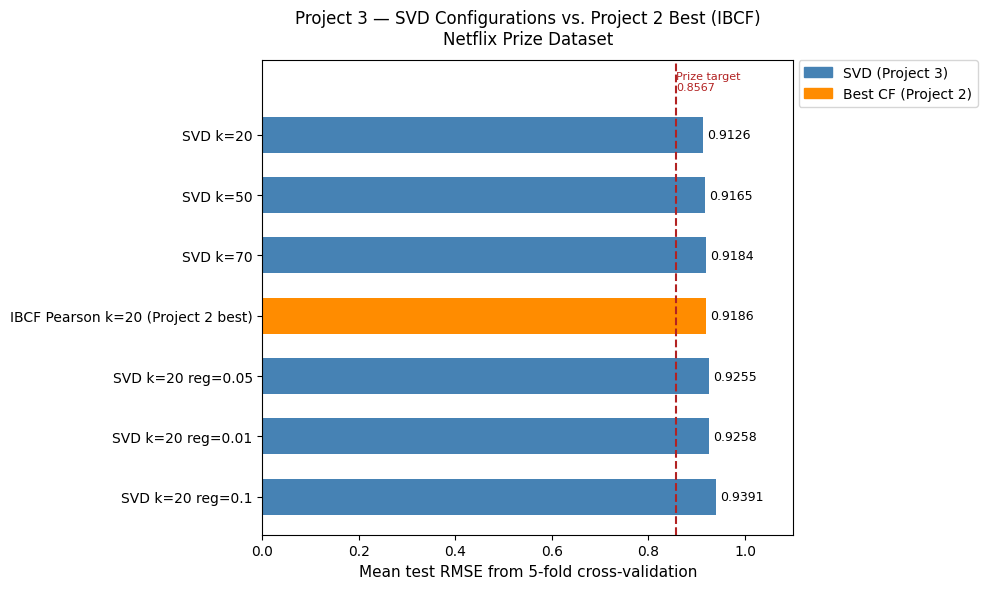

In [9]:
fig, ax = plt.subplots(figsize=(10, max(6, len(all_results) * 0.5 + 1)))
colors = ['darkorange' if 'Project 2' in lbl else 'steelblue' for lbl in all_results['label']]
bars = ax.barh(all_results['label'], all_results['rmse'], color=colors, height=0.6)

ax.axvline(TARGET, color='firebrick', linestyle='--', linewidth=1.5)   # Netflix Prize target
ax.text(TARGET + 0.001, -0.7, f'Prize target\n{TARGET}', color='firebrick', fontsize=8, va='bottom')

ax.bar_label(bars, labels=[f'{v:.4f}' for v in all_results['rmse']], padding=3, fontsize=9)
ax.set_xlabel('Mean test RMSE from 5-fold cross-validation', fontsize=11)
ax.set_title('Project 3 — SVD Configurations vs. Project 2 Best (IBCF)\nNetflix Prize Dataset', fontsize=12, pad=12)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax - 0.6)   # tighten bottom margin

svd_p = mpatches.Patch(color='steelblue', label='SVD (Project 3)')
p2_p  = mpatches.Patch(color='darkorange', label='Best CF (Project 2)')
ax.legend(handles=[svd_p, p2_p], loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0)

plt.tight_layout()
plt.savefig('p3_rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**SVD k=20 (RMSE 0.9126) edges out Project 2's best IBCF configuration (RMSE 0.9186)** — a modest but real improvement, and notably achieved with a *single* model rather than IBCF's neighbor-search machinery. More importantly, this is the smallest k tested, and the cheapest to compute and store. The gap to the 0.8567 Netflix Prize target has narrowed from roughly 0.062 (Project 2) to about 0.056 — real progress, but the Prize-winning result came from blending 100+ models, including SVD variants alongside several other techniques. A single SVD model alone was never going to close that gap on its own.

---
## 7. Where This Breaks — Devil's Advocate

Per Prof. Kowalchuk's repeated standing feedback: a recommender's failure modes matter more than its successes in a semester this short. Three specific ways this SVD model would fail in practice:

**Explainability.** The assignment notes this directly: "SVD builds features that may or may not map neatly to items." I have 20 latent factors per user and per movie, and no inherent way to say what factor 7 "means." Project 2's content-based filtering could at least point to genre tags as the reason for a recommendation; here, the only honest explanation is "the dot product of two learned vectors was high." For a production system facing "why was I shown this?" questions — regulatory or just for user trust — that's a real liability that content-based or hybrid approaches don't share.

**True cold start, not just sparsity.** Regularization handles *thin* data gracefully — a user with 5 ratings gets factors that lean more on the regularization term and less on that one user's specific taste, similar to how `KNNWithMeans` degraded gracefully in Project 2. But a user or movie with **zero** ratings has no factors to learn at all; `surprise`'s `SVD` falls back to predicting the global mean for anyone not seen during training. That's functionally identical to the Project 1 baseline — all of the matrix factorization machinery adds nothing for a brand-new user on day one. This was confirmed directly by Prof. Kowalchuk in the Week 3 session: pure CF and SVD both fail at true cold start, and only a baseline or a hybrid onboarding flow (the "ask a bunch of questions" pattern most apps use) handles it.

**Computational cost at real scale.** The assignment PDF flags this explicitly, and it held here too — even on a 500-movie, ~14K-user subset, the regularization sweep alone took meaningfully longer than the equivalent Project 2 KNN sweep, because every SGD epoch touches every observed rating, repeated across 5 folds × 4 configurations. At Netflix's actual scale (480K users × 17K movies in the full Prize dataset, not just this 500-movie slice), training would require either a much smaller k, distributed training, or the kind of Spark-based approach this course gets to in Project 5.

---
## 8. Good Metrics ≠ Good Recommender

RMSE 0.9126 and Precision@5 of 0.59 both look respectable in isolation. Neither one, on its own, tells you whether this is actually a *good* recommender to ship.

The coverage number (99.8%) is reassuring on one axis — this isn't a recommender that's quietly defaulting to "show everyone the same popular movies" — which is the most common way a system can post great accuracy metrics while actually being a pretty boring product that pushes everyone toward the same stuff. But coverage alone doesn't rule out a subtler version of the same problem: a movie can appear in *someone's* top-10 without the model being especially good at distinguishing genuine niche taste from noise. The latent factors are shaped mostly by the users and movies with the most ratings, so popular movies still get an edge baked into how the factors are learned in the first place — even if the top-10 lists look spread out by the coverage number.

The deeper issue is that none of these metrics — RMSE, MAE, precision, recall, coverage — check whether a recommendation is actually new to the user, or just a good surprise instead of something predictable. A model that mostly recommends movies similar to what a user already rated highly will score well on all five metrics here while still being a fairly boring recommender that never shows anyone anything they wouldn't have found on their own. Picking up the same point Project 2 raised: a production system needs metrics that look past the prediction-vs-actual-rating gap and ask what the recommendations are actually doing to a user's experience over time — something this project's evaluation, like most coursework evaluations, only partially captures.

---
## 9. Summary

**Best configuration: SVD, k=20, reg_all=0.02 — RMSE 0.9126, MAE 0.7151** — a modest improvement over Project 2's best IBCF result (RMSE 0.9186), achieved with a single trained model rather than a similarity search over all users or items.

**Key findings:**
- Smaller k (20) outperformed larger k (50, 70) on this dataset — more latent dimensions didn't help with only 500 movies and a 30-rating floor per user.
- `surprise`'s default regularization (0.02) was already near-optimal; both looser and tighter regularization made RMSE worse.
- Precision@5/Recall@5 (0.59 / 0.77) are solid, and 99.8% of the catalog shows up in someone's top-10 within the held-out test ratings — but that coverage figure is an offline diagnostic over each user's own test items, not full production catalog coverage, and neither metric nor RMSE tells you if a recommendation is genuinely new to the user or just a nice surprise.
- Checked directly (Section 5b) whether the RMSE-best config is also the recommendation-quality-best config, rather than assuming it: across all six SVD configurations tested, RMSE ranking and Precision@10 ranking agree at the top and stay closely aligned throughout. No accuracy-vs-recommendation-quality gap showed up here.
- SVD's missing-value handling (SGD over observed ratings only, per the assignment's "advanced" option) avoids imputation entirely, but doesn't solve true cold start — a brand-new user or movie still collapses to the global-mean baseline from Project 1.

**Citations:**
- Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix Factorization Techniques for Recommender Systems. *IEEE Computer*, 42(8), 30–37. https://datajobs.com/data-science-repo/Recommender-Systems-[Netflix].pdf
- Leskovec, J., Rajaraman, A., & Ullman, J. D. (2014). *Mining of Massive Datasets* (Ch. 9.4, 11.3). http://www.mmds.org/
- `scikit-surprise` documentation: https://surprise.readthedocs.io/
- Dataset, evaluation pattern (`run_cv`, 5-fold CV, RMSE+MAE chart style), and Project 2 baseline figure all carried forward from this series' own Project 2 notebook (`zg_data612_project_2_cb_and_collab_filtering.ipynb`).